# 03 · Customer Clustering with K-Means (Machine Learning)

**Goal:** let an **unsupervised ML algorithm** discover natural customer groups from R, F, M, and compare them with our rule-based RFM segments.

> 📘 **Unsupervised vs supervised learning**
> - *Supervised:* we have a target to predict (e.g. "will this customer churn?"). Notebook 05.
> - *Unsupervised:* no target; the algorithm finds structure on its own. Clustering is the classic example.
>
> 📘 **How K-Means works (in 4 lines):**
> 1. Pick *k* random points as cluster centres.
> 2. Assign every customer to the nearest centre.
> 3. Move each centre to the average of its customers.
> 4. Repeat 2-3 until nothing changes. It minimises the within-cluster distance (called *inertia*).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGS = ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.float_format", "{:,.2f}".format)

rfm = pd.read_parquet(PROCESSED / "rfm.parquet")

## 1. Pre-processing: why log + scaling?
K-Means uses **distances**, so two problems must be fixed first:
1. **Skew:** Monetary goes from £3 to £580,000. A few whales would dominate the distance. → apply `log1p` (log of 1+x) to compress big values.
2. **Different units:** days vs counts vs £. → `StandardScaler` rescales each feature to mean 0, std 1 so all three count equally.

*Interview tip:* "Forgetting to scale before K-Means" is a very common mistake. Mention that you handled it.

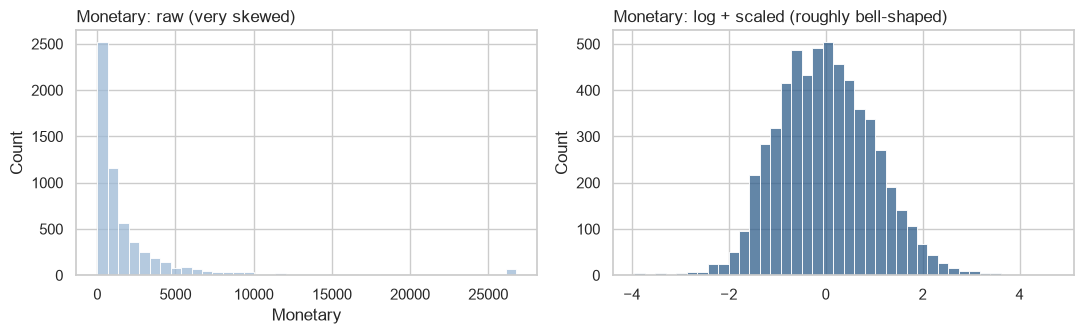

In [2]:
features = ["Recency", "Frequency", "Monetary"]
X_log = np.log1p(rfm[features])
scaler = StandardScaler()
X = scaler.fit_transform(X_log)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(rfm["Monetary"].clip(upper=rfm["Monetary"].quantile(.99)), ax=axes[0], bins=40, color="#9DB9D5")
axes[0].set_title("Monetary: raw (very skewed)", loc="left")
sns.histplot(X[:, 2], ax=axes[1], bins=40, color="#2F5D8A")
axes[1].set_title("Monetary: log + scaled (roughly bell-shaped)", loc="left")
plt.tight_layout(); plt.show()

## 2. Choosing k: Elbow method + Silhouette score
- **Elbow:** plot inertia vs k; pick the point where adding clusters stops helping much.
- **Silhouette score** (−1 to 1): how well each customer fits its own cluster vs the next nearest one. Higher = better-separated clusters.

Statistics alone rarely decide k. We also want clusters a **business can use** (not 2 = too crude, not 8 = too many to act on).

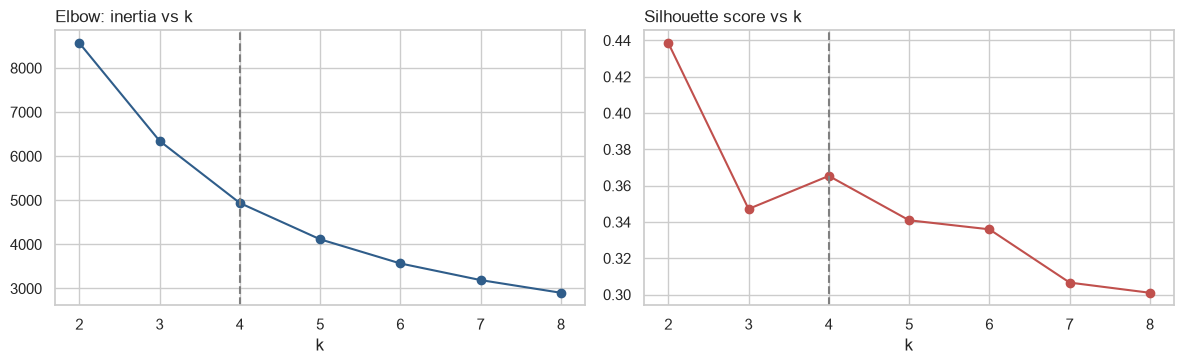

,inertia,silhouette
k,,
2,"8,568.46",0.44
3,"6,348.22",0.35
4,"4,938.79",0.37
5,"4,115.90",0.34
6,"3,567.91",0.34
7,"3,190.73",0.31
8,"2,902.86",0.30


In [3]:
ks = range(2, 9)
results = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    results.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(X, km.labels_)})
results = pd.DataFrame(results).set_index("k")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(results.index, results["inertia"], "o-", color="#2F5D8A"); axes[0].set_title("Elbow: inertia vs k", loc="left")
axes[1].plot(results.index, results["silhouette"], "o-", color="#C0504D"); axes[1].set_title("Silhouette score vs k", loc="left")
for ax in axes: ax.axvline(4, ls="--", color="grey"); ax.set_xlabel("k")
plt.tight_layout(); plt.savefig(FIGS / "03_choose_k.png", dpi=150); plt.show()
results

**Decision: k = 4.** Silhouette is highest at k=2, but 2 groups ("good" vs "bad") is too crude to act on. Among k ≥ 3, **k=4 has the best silhouette** and it sits at the elbow. Good statistics *and* business usability.

In [4]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X)
rfm["Cluster"] = kmeans.labels_

## 3. Profile and name the clusters
The algorithm returns numbers (0-3); an analyst's job is to **interpret** them. We look at median R, F, M of each cluster and name it.

In [5]:
prof = rfm.groupby("Cluster").agg(Customers=("CustomerID", "size"), Recency=("Recency", "median"),
                                  Frequency=("Frequency", "median"), Monetary=("Monetary", "median"),
                                  Revenue=("Monetary", "sum"))

# Naming rule (robust to the arbitrary cluster numbering):
#   highest median spend → Active High-Value; highest recency (longest gone) → Dormant;
#   of the remaining two, the more recent → Recent Developing, the other → Lapsing Mid-Value
names = {}
names[prof["Monetary"].idxmax()] = "Active High-Value"
names[prof["Recency"].idxmax()] = "Dormant"
rest = prof.drop(index=list(names)).sort_values("Recency")
names[rest.index[0]] = "Recent Developing"
names[rest.index[1]] = "Lapsing Mid-Value"

rfm["ClusterName"] = rfm["Cluster"].map(names)
prof = prof.rename(index=names).assign(**{"% Revenue": lambda d: d.Revenue / d.Revenue.sum() * 100}) \
           .sort_values("Revenue", ascending=False)
prof

,Customers,Recency,Frequency,Monetary,Revenue,% Revenue
Cluster,,,,,,
Active High-Value,1109,15.00,13.00,"5,115.36","12,013,363.58",71.71
Lapsing Mid-Value,1470,157.00,5.00,"1,579.60","3,041,501.63",18.15
Recent Developing,1220,23.00,3.00,707.66,"1,002,636.17",5.98
Dormant,2053,399.00,1.00,290.34,"696,000.96",4.15


| Cluster | Who they are | Action |
|---|---|---|
| **Active High-Value** | Bought ~2 weeks ago, many orders, big spend | Retain: VIP treatment |
| **Recent Developing** | Recent but few orders, small spend | Grow: nudge the 2nd/3rd purchase |
| **Lapsing Mid-Value** | Decent history but ~5 months since last order | Win back before they're lost |
| **Dormant** | One small order, over a year ago | Low-cost campaigns only |

## 4. Visualise clusters in 2-D with PCA
> 📘 **PCA (Principal Component Analysis)** squeezes our 3 features into 2 "summary" axes that keep most of the variation, so we can draw the clusters on a flat chart.

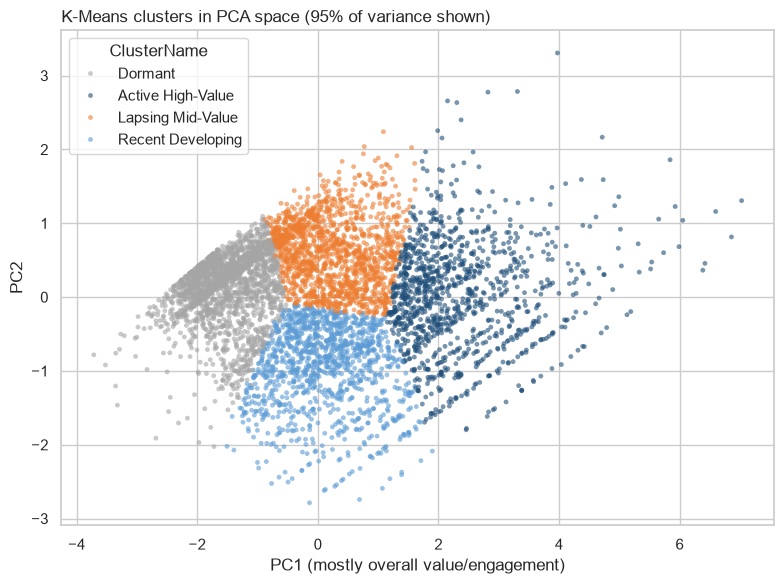

In [6]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X)
palette = {"Active High-Value": "#1F4E79", "Recent Developing": "#5B9BD5", "Lapsing Mid-Value": "#ED7D31", "Dormant": "#A5A5A5"}
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=rfm["ClusterName"], palette=palette, s=12, alpha=.6, ax=ax, linewidth=0)
ax.set_title(f"K-Means clusters in PCA space ({pca.explained_variance_ratio_.sum():.0%} of variance shown)", loc="left")
ax.set_xlabel("PC1 (mostly overall value/engagement)"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.savefig(FIGS / "03_clusters_pca.png", dpi=150); plt.show()

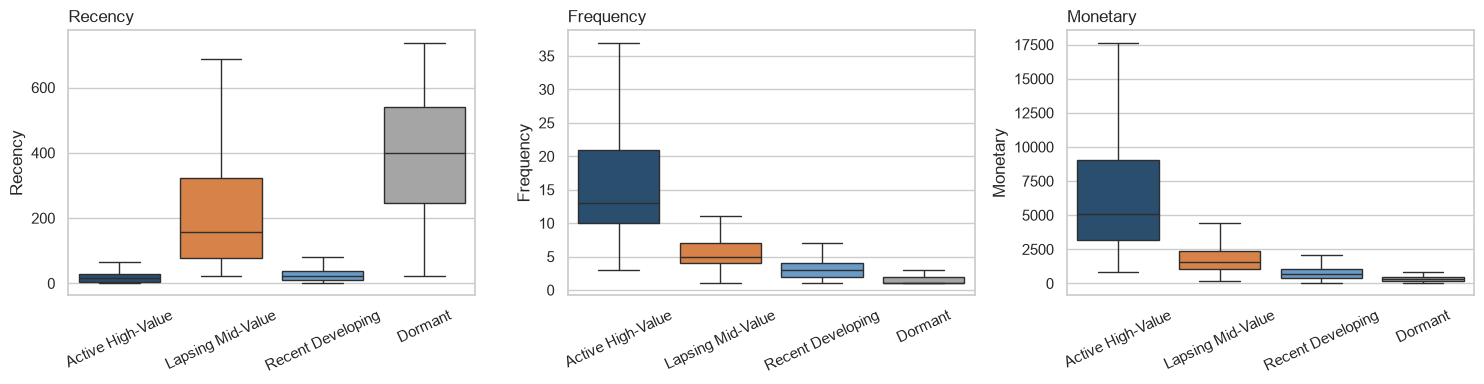

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = list(prof.index)
for ax, col in zip(axes, features):
    sns.boxplot(data=rfm, x="ClusterName", y=col, order=order, palette=palette, hue="ClusterName", ax=ax, showfliers=False)
    ax.set_title(col, loc="left"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.savefig(FIGS / "03_cluster_boxplots.png", dpi=150); plt.show()

## 5. Do ML clusters agree with the RFM rules? (Validation)
A cross-tab shows how the 10 rule-based segments fall into the 4 data-driven clusters. Strong agreement means both methods found **real structure**, not noise.

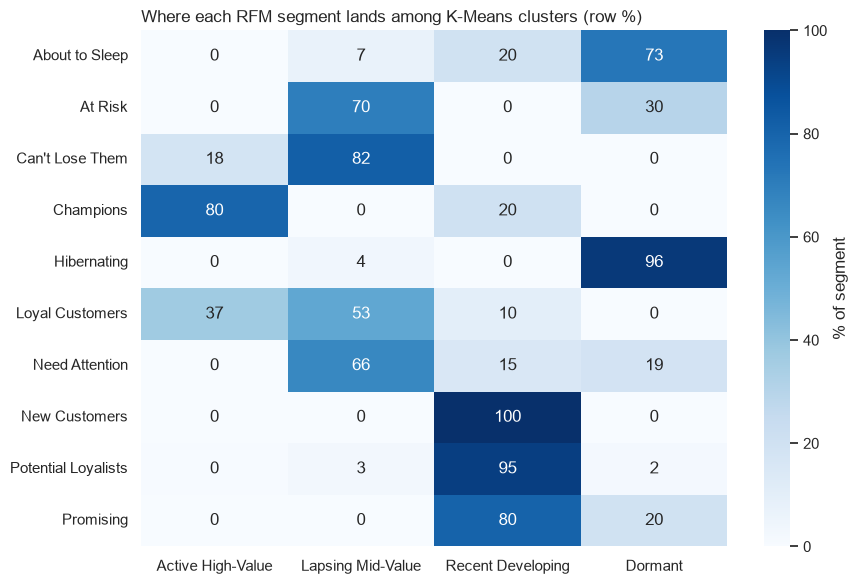

In [8]:
ct = pd.crosstab(rfm["Segment"], rfm["ClusterName"], normalize="index")[order] * 100
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(ct, annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "% of segment"})
ax.set_title("Where each RFM segment lands among K-Means clusters (row %)", loc="left")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(FIGS / "03_rfm_vs_kmeans.png", dpi=150); plt.show()

In [9]:
rfm.to_parquet(PROCESSED / "rfm_clusters.parquet", index=False)
print("Saved rfm_clusters.parquet")

Saved rfm_clusters.parquet


## ✅ Key takeaways
1. Log-transform + standardise before K-Means, because distance-based methods are sensitive to skew and units.
2. k=4 chosen using elbow + silhouette **and** business interpretability.
3. Clusters line up with RFM segments (e.g. Champions → Active High-Value), which validates both approaches.
4. **RFM rules** = transparent and easy to explain to stakeholders; **K-Means** = data-driven and scales to more features (e.g. return rate, product mix). In practice you'd use both.

**Limitations:** K-Means assumes roughly round, similar-sized clusters and needs k chosen upfront; results depend on the features chosen.